# A3: Car Price Prediction
**Name:** Lin Htet Aung  
**Student ID:** st127132  
**Github:** https://github.com/linhtetaung-mm/car-price-prediction

For this assignment, we will use the same car dataset from A1 and A2. This time, we will predict a price category instead of an exact selling price.

- **Task 1:** Convert the price into four classes, implement logistic regression and calculate the classification metrics.
- **Task 2:** Add the option to use ridge regularization.
- **Task 3:** Record the experiments in MLflow, register the best model and prepare automated testing and deployment.

I kept the cleaning steps from my previous assignments. The main changes start when we create the price classes.

## 1. Imports; Load Data

In [34]:
from pathlib import Path
import sys
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import joblib
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report as sklearn_report

# Allow this notebook to run from the notebooks folder or the project root.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "a3").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

os.environ.setdefault("MLFLOW_DISABLE_AGENT_HINT", "1")
from a3.data import FEATURES, PRICE_EDGES, PRICE_LABELS, clean_data, price_classes
from a3.model import LogisticRegression
from a3.metrics import classification_report, confusion_matrix

RANDOM_STATE = 42
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)

NumPy: 2.5.2
pandas: 3.0.5
scikit-learn: 1.9.0


In [2]:
# Load the original data, as in A1 and A2.
raw_df = pd.read_csv(PROJECT_ROOT / "data/Cars.csv")
df = raw_df.copy()
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 1.6 MB


## 2. Data Cleaning

These are the cleaning steps from my A1 notebook. I am showing them again so we can see which rows are used for A3.

In [4]:
# Before we do anything, I want to check nulls and duplicates first
print("Original shape:", df.shape)
print("Original missing values:")
display(df.isnull().sum())

print("Original exact duplicates:", df.duplicated().sum())

Original shape: (8128, 13)
Original missing values:


name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

Original exact duplicates: 1202


In [5]:
# As per instructions, we do these steps

# Remove fuel types that use a different mileage unit
df = df.loc[~df["fuel"].isin(["CNG", "LPG"])].copy()

# Map the remaining ordered owner categories
owner_mapping = {
    "First Owner": 1,
    "Second Owner": 2,
    "Third Owner": 3,
    "Fourth & Above Owner": 4,
    "Test Drive Car": 5
}
df["owner"] = df["owner"].map(owner_mapping)

# Extract numbers from these column units, invalid or missing strings become NaN.
for column in ["mileage", "engine", "max_power"]:
    df[column] = pd.to_numeric(
        df[column]
        .astype("string")
        .str.extract(
            r"([-+]?\d*\.?\d+)",
            expand=False
        ),
        errors="coerce"
    )

# Rename "name" to "brand" and get only first word
df.rename(columns={'name': 'brand'},inplace=True)
df["brand"] = df["brand"].str.split().str[0]

# Drop unwanted columns
df = df.drop(columns=["torque"])


In [6]:
display(df.head(10))

,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.4,1248,74.0,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.7,1497,78.0,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23.0,1396,90.0,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.1,1298,88.2,5.0
5,Hyundai,2017,440000,45000,Petrol,Individual,Manual,1,20.14,1197,81.86,5.0
7,Maruti,2001,45000,5000,Petrol,Individual,Manual,2,16.1,796,37.0,4.0
8,Toyota,2011,350000,90000,Diesel,Individual,Manual,1,23.59,1364,67.1,5.0
9,Ford,2013,200000,169000,Diesel,Individual,Manual,1,20.0,1399,68.1,5.0
10,Renault,2014,500000,68000,Diesel,Individual,Manual,2,19.01,1461,108.45,5.0


In [7]:
# Let's see what is wrong with Test Drive Cars(coded as 5)
display(df[df['owner'] == 5])


,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
4383,Volkswagen,2019,1350000,5400,Diesel,Dealer,Manual,5,22.27,1498,108.6,5.0
4950,Audi,2019,6223000,7800,Petrol,Dealer,Automatic,5,15.26,1798,187.74,5.0
4951,Audi,2019,5923000,11500,Petrol,Dealer,Automatic,5,15.26,1798,187.74,5.0
4952,Audi,2019,6523000,23600,Petrol,Dealer,Automatic,5,15.26,1798,187.74,5.0
6220,Honda,2019,2000000,24857,Petrol,Dealer,Automatic,5,16.5,1799,139.46,5.0


In [8]:
# Wow, they are really expensive
# We will delete them as per instruction
df = df.loc[df["owner"] != 5].copy()


In [9]:
# After done as per instructions, we will check nulls and duplicates again
print("After instructions")
print("Shape:", df.shape)
print("Missing values:")
display(df.isnull().sum())

print("Exact duplicates:", df.duplicated().sum())

After instructions
Shape: (8028, 12)
Missing values:


brand              0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          214
engine           214
max_power        208
seats            214
dtype: int64

Exact duplicates: 1220


In [10]:
# We will look at null values and see if we should impute or delete rows

required_columns = ["mileage", "engine", "max_power", "seats"]

missing_mask = df[required_columns].isnull().any(axis=1)
null_rows_df = df.loc[missing_mask].copy()

print("Rows with missing required values:", len(null_rows_df))
print(f"Percentage affected: {missing_mask.mean() * 100:.2f}%")

display(
    null_rows_df[
        required_columns
        + ["brand", "year", "selling_price"]
    ].head(10)
)

Rows with missing required values: 214
Percentage affected: 2.67%


,mileage,engine,max_power,seats,brand,year,selling_price
13,<NA>,<NA>,<NA>,NaN,Maruti,2007,200000
31,<NA>,<NA>,<NA>,NaN,Fiat,2003,70000
78,<NA>,<NA>,<NA>,NaN,Tata,2003,50000
87,<NA>,<NA>,<NA>,NaN,Maruti,2015,475000
119,<NA>,<NA>,<NA>,NaN,Maruti,2010,300000
138,<NA>,<NA>,<NA>,NaN,BMW,2017,2150000
200,<NA>,<NA>,<NA>,NaN,Toyota,2012,235000
206,<NA>,<NA>,<NA>,NaN,Maruti,2003,40000
228,<NA>,<NA>,<NA>,NaN,Maruti,2008,130000
252,<NA>,<NA>,<NA>,NaN,Tata,2005,75000


In [11]:
# As we see, those null values are happening in the same rows.
# And the percentage is very small too, so we will delete those rows.'
df = (
    df.loc[~missing_mask]
    .copy()
    .reset_index(drop=True)
)

In [12]:
# After deleting rows with missing values
print("After deleting nulls:")
print("Shape:", df.shape)
print("Missing values:")
display(df.isnull().sum())

print("Exact duplicates:", df.duplicated().sum())

After deleting nulls:
Shape: (7814, 12)
Missing values:


brand            0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
dtype: int64

Exact duplicates: 1207


In [13]:
# Now we will see duplicated rows

# "keep= False" means include first occurance
duplicate_rows_df = df.loc[df.duplicated(keep=False)].copy()

print("Rows involved in duplicate groups:", len(duplicate_rows_df))
print("Duplicate copies to remove:", df.duplicated().sum())

display(
    duplicate_rows_df
    .sort_values(by=list(df.columns))
    .head(10)
)

Rows involved in duplicate groups: 1831
Duplicate copies to remove: 1207


,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
2051,Audi,2014,1850000,76131,Diesel,Individual,Automatic,1,13.22,2967,241.4,5.0
7467,Audi,2014,1850000,76131,Diesel,Individual,Automatic,1,13.22,2967,241.4,5.0
1905,Audi,2017,2825000,22000,Diesel,Dealer,Automatic,1,15.73,1968,174.33,5.0
7035,Audi,2017,2825000,22000,Diesel,Dealer,Automatic,1,15.73,1968,174.33,5.0
123,Audi,2018,3975000,31800,Diesel,Dealer,Automatic,1,17.01,1968,188.0,5.0
1502,Audi,2018,3975000,31800,Diesel,Dealer,Automatic,1,17.01,1968,188.0,5.0
1791,Audi,2018,3975000,31800,Diesel,Dealer,Automatic,1,17.01,1968,188.0,5.0
3100,Audi,2018,3975000,31800,Diesel,Dealer,Automatic,1,17.01,1968,188.0,5.0
5040,Audi,2018,3975000,31800,Diesel,Dealer,Automatic,1,17.01,1968,188.0,5.0
7394,Audi,2018,3975000,31800,Diesel,Dealer,Automatic,1,17.01,1968,188.0,5.0


Note: Since we only use the first word from "name",\
we may have more duplicates after doing as instructed.

In [14]:
# Delete all those duplicates
df = (
    df.drop_duplicates()
    .reset_index(drop=True)
    .copy()
)

In [15]:
# After deleting duplicated rows
print("After deleting duplicates:")
print("Shape:", df.shape)
print("Exact duplicates:", df.duplicated().sum())

After deleting duplicates:
Shape: (6607, 12)
Exact duplicates: 0


In [16]:
# The training script uses clean_data(). Check that it gives the same rows.
script_df = clean_data(raw_df)
pd.testing.assert_frame_equal(df, script_df, check_dtype=False)
print("Notebook cleaning and training-script cleaning match.")

Notebook cleaning and training-script cleaning match.


Note: We now have 6,607 rows. Like A1/A2, we removed CNG/LPG cars, test-drive cars, rows missing the four required specifications and duplicate rows. We also mapped the owner values, extracted the numeric units and kept only the brand from the car name.

We will keep the same 11 input features. Imputation, scaling and one-hot encoding are done later, using only training rows.

## 3. EDA and Price Classes — Task 1

In A1/A2, I used log selling price for regression. Here, we need four labels: 0, 1, 2 and 3. I will use the original rupee prices and the fixed boundaries below.

| Class | Selling price (INR) |
|---|---|
| 0 | 0 < price ≤ 300,000 |
| 1 | 300,000 < price ≤ 600,000 |
| 2 | 600,000 < price ≤ 1,000,000 |
| 3 | price > 1,000,000 |

These ranges are not equal in width or count. I chose them so the predicted category has a clear price range. The boundaries are fixed, so they do not need to be calculated from test prices.

In [17]:
# Put each selling price into its price class.
df["price_class"] = pd.cut(
    df["selling_price"],
    bins=PRICE_EDGES,
    labels=[0, 1, 2, 3],
    right=True,
).astype(int)

# Check that the function used by the training script follows the same rule.
np.testing.assert_array_equal(df["price_class"], price_classes(df["selling_price"]))
display(df[["selling_price", "price_class"]].head(10))

,selling_price,price_class
0,450000,1
1,370000,1
2,158000,0
3,225000,0
4,130000,0
5,440000,1
6,45000,0
7,350000,1
8,200000,0
9,500000,1


,count,percentage
price_class,,
0,2234,33.81
1,2514,38.05
2,1390,21.04
3,469,7.10


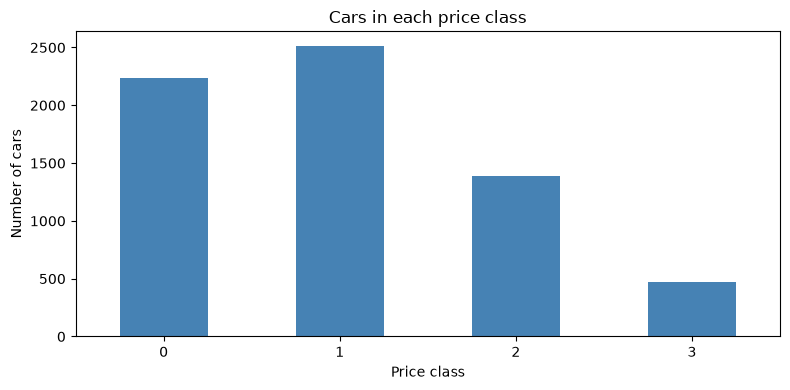

In [18]:
# Check the count and percentage of each class before training.
class_counts = df["price_class"].value_counts().sort_index()
class_summary = pd.DataFrame({
    "count": class_counts,
    "percentage": class_counts / len(df) * 100,
})
display(class_summary.round(2))

class_counts.plot.bar(color="steelblue", rot=0, figsize=(8, 4))
plt.xlabel("Price class")
plt.ylabel("Number of cars")
plt.title("Cars in each price class")
plt.tight_layout()
plt.show()

### What I observed

The classes are imbalanced. Class 1 has the most cars, while class 3 has the fewest. Accuracy alone can hide poor predictions for a smaller class, so I will use **macro F1** to select the model. It gives each of the four classes the same importance.

Using `pd.cut(..., bins=4)` would give equal-width intervals across the full price range. That is different from the explicit boundaries above. Quantile buckets would be another valid choice, but they would define a different prediction task.

## 4. Train-Test Split and Preprocessing

In [19]:
X = df[FEATURES]
y = df["price_class"].to_numpy()

# Keep 20% for the final test. Stratify keeps similar class proportions.
train_index, test_index = train_test_split(
    np.arange(len(df)),
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)
X_train = X.iloc[train_index]
X_test = X.iloc[test_index]
y_train = y[train_index]
y_test = y[test_index]

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
display(pd.DataFrame({
    "train": np.bincount(y_train, minlength=4),
    "test": np.bincount(y_test, minlength=4),
}, index=pd.Index(range(4), name="Class")))

Training shape: (5285, 11)
Test shape: (1322, 11)


,train,test
Class,,
0,1787,447
1,2011,503
2,1112,278
3,375,94


The numerical inputs use median imputation and standard scaling. Categorical inputs use most-frequent imputation and one-hot encoding. This is the same basic preprocessing as A2, without polynomial terms.

For cross-validation, the preprocessor is fitted again inside each training fold. We do not fit it on the full dataset before splitting. The test data stays separate until the best configuration is selected.

## 5. Logistic Regression and Metrics — Task 1

### 5.1 Model implementation

The model is in [a3/model.py](../a3/model.py). Like the separate class file in A2, this lets the notebook and application use the same implementation.

The class follows the course multinomial logistic regression example:

1. Start with zero weights and a separate bias for each class.
2. Calculate four scores for each car.
3. Apply softmax to turn those scores into probabilities.
4. Calculate cross-entropy loss and update the weights using batch gradient descent.
5. Predict the class with the highest probability.

The maximum score is subtracted before exponentiation to keep the softmax calculation stable. Training is written with NumPy; sklearn is used for preprocessing and the pipeline, not to train our logistic regression.

In [20]:
# A small example to check the model before using the car data.
# Each input pattern belongs to a different class.
example_X = np.repeat(np.eye(4), 10, axis=0)
example_y = np.repeat(np.arange(4), 10)
example_model = LogisticRegression(lr=0.3, num_epochs=600, l2=0)
example_model.fit(example_X, example_y)

print("Predicted classes:", example_model.predict(np.eye(4)))
display(pd.DataFrame(
    example_model.predict_proba(np.eye(4)),
    columns=["Class 0", "Class 1", "Class 2", "Class 3"],
).round(3))

Predicted classes: [0 1 2 3]


,Class 0,Class 1,Class 2,Class 3
0,0.982,0.006,0.006,0.006
1,0.006,0.982,0.006,0.006
2,0.006,0.006,0.982,0.006
3,0.006,0.006,0.006,0.982


### 5.2 Classification metrics

The calculations are in [a3/metrics.py](../a3/metrics.py). The model inherits these methods so we can call `model.precision(...)`, `model.macro_f1(...)`, and the other required functions.

For each class, we calculate true positives, false positives and false negatives from the confusion matrix. Rows are the actual classes, and columns are the predicted classes.

- **Accuracy:** correct predictions / total predictions.
- **Precision:** TP / (TP + FP).
- **Recall:** TP / (TP + FN).
- **F1:** 2 × precision × recall / (precision + recall).
- **Macro average:** average the four class scores.
- **Weighted average:** multiply each class score by its support / total, then add them.

If a denominator is zero, the score is set to zero. This matches sklearn with `zero_division=0`.

In [21]:
# Use a few labels so we can check the calculations ourselves.
y_true_mock = np.array([0, 0, 0, 1, 1, 2, 3, 3])
y_pred_mock = np.array([0, 1, 0, 1, 2, 2, 0, 3])

matrix = confusion_matrix(y_true_mock, y_pred_mock)
display(pd.DataFrame(
    matrix,
    index=pd.Index(range(4), name="Actual"),
    columns=pd.Index(range(4), name="Predicted"),
))

# For class 0, read TP, FP and FN from its row and column.
true_positive = matrix[0, 0]
false_positive = matrix[:, 0].sum() - true_positive
false_negative = matrix[0, :].sum() - true_positive
print("Class 0 TP, FP, FN:", true_positive, false_positive, false_negative)
print("Class 0 precision:", true_positive / (true_positive + false_positive))
print("Class 0 recall:", true_positive / (true_positive + false_negative))

Predicted,0,1,2,3
Actual,,,,
0,2,1,0,0
1,0,1,1,0
2,0,0,1,0
3,1,0,0,1


Class 0 TP, FP, FN: 2 1 1
Class 0 precision: 0.6666666666666666
Class 0 recall: 0.6666666666666666


In [22]:
# Check each function requested in Task 1.
metric_model = LogisticRegression()
print("Accuracy:", metric_model.accuracy(y_true_mock, y_pred_mock))
print("Precision:", metric_model.precision(y_true_mock, y_pred_mock))
print("Recall:", metric_model.recall(y_true_mock, y_pred_mock))
print("F1:", metric_model.f1_score(y_true_mock, y_pred_mock))

average_scores = pd.DataFrame({
    "precision": [
        metric_model.macro_precision(y_true_mock, y_pred_mock),
        metric_model.weighted_precision(y_true_mock, y_pred_mock),
    ],
    "recall": [
        metric_model.macro_recall(y_true_mock, y_pred_mock),
        metric_model.weighted_recall(y_true_mock, y_pred_mock),
    ],
    "f1-score": [
        metric_model.macro_f1(y_true_mock, y_pred_mock),
        metric_model.weighted_f1(y_true_mock, y_pred_mock),
    ],
}, index=["macro avg", "weighted avg"])
display(average_scores)

Accuracy: 0.625
Precision: [0.66666667 0.5        0.5        1.        ]
Recall: [0.66666667 0.5        1.         0.5       ]
F1: [0.66666667 0.5        0.66666667 0.66666667]


,precision,recall,f1-score
macro avg,0.666667,0.666667,0.625
weighted avg,0.687500,0.625000,0.625


### 5.3 Compare with sklearn

In [24]:
my_report = classification_report(y_true_mock, y_pred_mock)
sklearn_result = sklearn_report(
    y_true_mock, y_pred_mock,
    labels=[0, 1, 2, 3], output_dict=True, zero_division=0,
)

# Put the two reports next to each other.
report_rows = ["0", "1", "2", "3", "macro avg", "weighted avg"]
my_table = pd.DataFrame([my_report[row] for row in report_rows], index=report_rows)
sklearn_table = pd.DataFrame([sklearn_result[row] for row in report_rows], index=report_rows)
display(pd.concat({"My calculation": my_table, "sklearn": sklearn_table}, axis=1))

np.testing.assert_allclose(my_table, sklearn_table, atol=1e-12)
np.testing.assert_allclose(my_report["accuracy"], sklearn_result["accuracy"], atol=1e-12)
print("Both reports match.")

My calculation                               sklearn            \
                  precision    recall  f1-score support precision    recall   
0                  0.666667  0.666667  0.666667       3  0.666667  0.666667   
1                  0.500000  0.500000  0.500000       2  0.500000  0.500000   
2                  0.500000  1.000000  0.666667       1  0.500000  1.000000   
3                  1.000000  0.500000  0.666667       2  1.000000  0.500000   
macro avg          0.666667  0.666667  0.625000       8  0.666667  0.666667   
weighted avg       0.687500  0.625000  0.625000       8  0.687500  0.625000   

                                
              f1-score support  
0             0.666667     3.0  
1             0.500000     2.0  
2             0.666667     1.0  
3             0.666667     2.0  
macro avg     0.625000     8.0  
weighted avg  0.625000     8.0

Both reports match.


**What does support mean?**

Support is the number of actual samples in a class. For example, class 0 has support 3 in the mock data because there are three zeros in `y_true_mock`. It is not the number of predictions for class 0.

Note: The weighted-average example in the assignment includes an extra division by four. I did not use that extra division because the support weights already add up to one. The comparison above confirms the result with sklearn.

## 6. Ridge Logistic Regression — Task 2

We can choose whether to use ridge by setting `l2`. With `l2=0`, there is no penalty. A positive value adds a cost for large weights.

The loss used in the code is:

$$J(W,b) = -\frac{1}{m}\sum_i \log p_{i,y_i} + \lambda\sum_{j,c}W_{jc}^2.$$

The weight gradient is `X.T @ (probabilities - one_hot_y) / m + 2 * l2 * weights`. The bias is stored separately and is not penalized.

I use the **mean** cross-entropy loss, while the assignment writes a sum. For the same objective after dividing by the number of samples, the assignment's lambda would be `m * l2`.

In [25]:
# These two models differ only in whether the ridge penalty is used.
normal_model = LogisticRegression(lr=0.3, num_epochs=600, l2=0)
ridge_model = LogisticRegression(lr=0.3, num_epochs=600, l2=0.0001)
print("No penalty:", normal_model.l2)
print("Ridge penalty:", ridge_model.l2)

No penalty: 0
Ridge penalty: 0.0001


## 7. Experiments with MLflow

As in A2, the experiment loop is in a separate file: [a3/train.py](../a3/train.py).

I compare three learning rates (`0.03`, `0.1`, `0.3`) and four L2 strengths (`0`, `0.0001`, `0.001`, `0.01`). This gives **12 configurations**. Each uses five stratified folds and up to 600 batch-gradient epochs.

The best configuration has the highest mean CV macro F1. Ties are broken by CV accuracy and then smaller L2. All model selection uses the training set.

Set `RUN_EXPERIMENTS = True` to run the full experiment again. With `False`, the next cells read the saved results. Parameters, fold scores and each fitted pipeline are recorded in local MLflow; the dataset is not logged.

In [26]:
from a3.train import run_experiments, fit_model

RUN_EXPERIMENTS = False
if RUN_EXPERIMENTS:
    run_experiments()

results = pd.read_csv(PROJECT_ROOT / "data/a3_experiment_results.csv")
summary = json.loads((PROJECT_ROOT / "data/a3_best_model_summary.json").read_text())

comparison_columns = [
    "lr", "l2", "num_epochs",
    "cv_accuracy", "cv_macro_f1_score", "cv_macro_f1_std",
]
display(results[comparison_columns])

,lr,l2,num_epochs,cv_accuracy,cv_macro_f1_score,cv_macro_f1_std
0,0.30,0.0001,600,0.780322,0.769586,0.013917
1,0.30,0.0000,600,0.780132,0.769546,0.013918
2,0.30,0.0010,600,0.778430,0.765527,0.015066
3,0.10,0.0001,600,0.762535,0.738215,0.015024
4,0.10,0.0000,600,0.762346,0.738067,0.015045
5,0.10,0.0010,600,0.761779,0.737389,0.012334
6,0.30,0.0100,600,0.752696,0.723716,0.014013
7,0.10,0.0100,600,0.744371,0.710436,0.013902
8,0.03,0.0010,600,0.724693,0.680586,0.010800
9,0.03,0.0001,600,0.723179,0.679070,0.011030


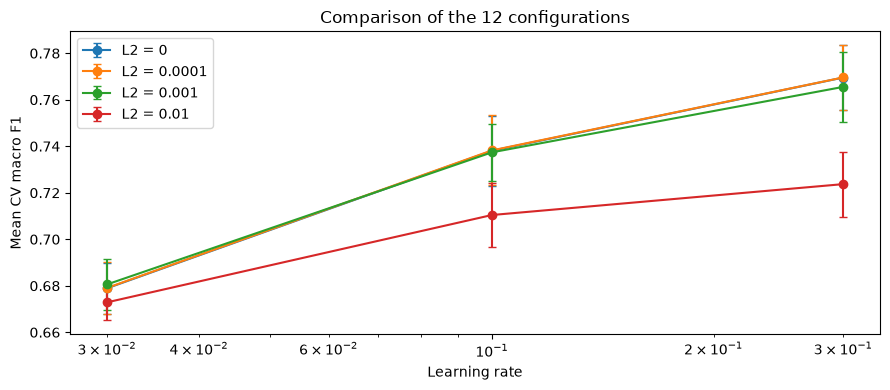

In [27]:
# Compare the learning rates for each ridge strength.
fig, ax = plt.subplots(figsize=(9, 4))
for l2, group in results.groupby("l2"):
    group = group.sort_values("lr")
    ax.errorbar(
        group["lr"], group["cv_macro_f1_score"],
        yerr=group["cv_macro_f1_std"],
        marker="o", capsize=3, label=f"L2 = {l2:g}",
    )
ax.set_xscale("log")
ax.set_xlabel("Learning rate")
ax.set_ylabel("Mean CV macro F1")
ax.set_title("Comparison of the 12 configurations")
ax.legend()
plt.tight_layout()
plt.show()

Note: The error bars show the standard deviation across the five folds. They show how much the score changes between folds, not a confidence interval.

The best ridge result and best unregularized result are almost the same. We should not conclude that ridge clearly improves the model from this small difference. Also, all runs have the same epoch limit, so a lower learning rate may need more epochs.

## 8. Best Model and Test Results

In [28]:
best = results.iloc[0]
print("Best learning rate:", best["lr"])
print("Best L2:", best["l2"])
print("Mean CV macro F1:", best["cv_macro_f1_score"])

# Fit the selected settings on all training rows.
best_pipeline = fit_model(
    X_train, y_train,
    lr=float(best["lr"]),
    l2=float(best["l2"]),
    epochs=int(best["num_epochs"]),
)
y_pred = best_pipeline.predict(X_test)

# The file used by the application should produce the same predictions.
saved_pipeline = joblib.load(PROJECT_ROOT / "models/best_a3_model.joblib")
np.testing.assert_array_equal(y_pred, saved_pipeline.predict(X_test))

Best learning rate: 0.3
Best L2: 0.0001
Mean CV macro F1: 0.7695857250448033


In [29]:
test_report = classification_report(y_test, y_pred)
display(pd.DataFrame([test_report[row] for row in report_rows], index=report_rows))

print("Test accuracy:", test_report["accuracy"])
print("Test macro F1:", test_report["macro avg"]["f1-score"])
print("Majority-class baseline:", summary["majority_baseline_accuracy"])

# Check the real-data report too, not just the small example.
reference = sklearn_report(
    y_test, y_pred, labels=[0, 1, 2, 3],
    output_dict=True, zero_division=0,
)
for row in report_rows:
    for metric in ["precision", "recall", "f1-score", "support"]:
        np.testing.assert_allclose(test_report[row][metric], reference[row][metric], atol=1e-12)
np.testing.assert_allclose(test_report["accuracy"], summary["test_metrics"]["test_accuracy"])
print("The test report also matches sklearn and the saved result.")

,precision,recall,f1-score,support
0,0.880000,0.836689,0.857798,447
1,0.711230,0.793241,0.750000,503
2,0.666667,0.633094,0.649446,278
3,0.791667,0.606383,0.686747,94
macro avg,0.762391,0.717352,0.735998,1322
weighted avg,0.764643,0.760968,0.760806,1322


Test accuracy: 0.7609682299546142
Test macro F1: 0.7359979118885916
Majority-class baseline: 0.3804841149773071
The test report also matches sklearn and the saved result.


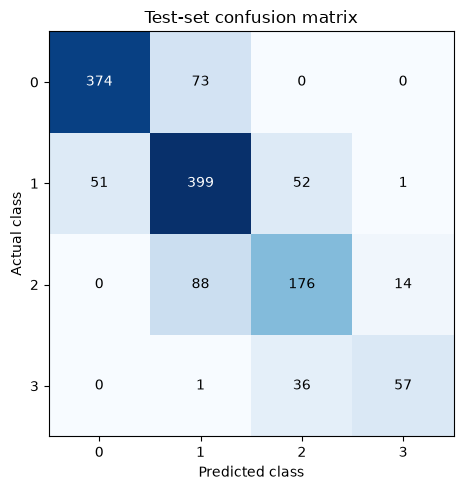

In [30]:
# Look at which classes are confused with one another.
matrix = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(matrix, cmap="Blues")
for row in range(4):
    for column in range(4):
        value = matrix[row, column]
        color = "white" if value > matrix.max() / 2 else "black"
        ax.text(column, row, str(value), ha="center", va="center", color=color)
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")
ax.set_title("Test-set confusion matrix")
plt.tight_layout()
plt.show()

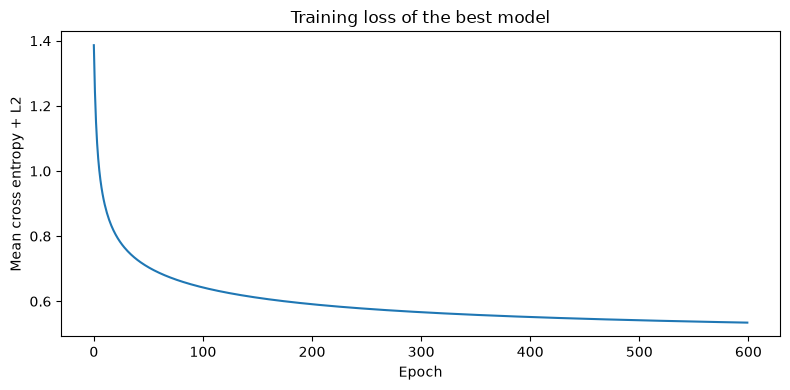

In [31]:
# Check the loss during training of the selected model.
plt.figure(figsize=(8, 4))
plt.plot(best_pipeline.named_steps["classifier"].loss_history_)
plt.xlabel("Epoch")
plt.ylabel("Mean cross entropy + L2")
plt.title("Training loss of the best model")
plt.tight_layout()
plt.show()

## 9. Report and Findings

### Best configuration

The selected model uses a learning rate of **0.3** and L2 of **0.0001**. Its mean CV macro F1 is **0.7696**. The best model without regularization scores **0.7695**, so the difference is only about **0.00004** before rounding. This is much smaller than the fold standard deviation of about **0.014**.

### Test-set result

| Metric | Score |
|---|---:|
| Accuracy | 0.7610 |
| Macro F1 | 0.7360 |
| Weighted F1 | 0.7608 |
| Majority-class baseline accuracy | 0.3805 |

The model does better than always predicting the most common class. However, the class scores are not equally strong. Class 0 has F1 **0.8578**, while class 2 has F1 **0.6494**. Of the 278 actual class-2 cars, 88 are predicted as class 1. Class 3 also misses some expensive cars: 36 of its 94 samples are predicted as class 2.

### What I observed

Most errors are between nearby price bands. A car close to a boundary may have similar features to cars on the other side. The current model also uses linear boundaries after preprocessing, so it may miss more complicated relationships between features.

Stronger regularization (`l2=0.01`) gave lower CV scores in this experiment. A small penalty was selected, but the results do not show a clear advantage over no penalty. I would need more evidence before claiming that ridge is better here.

These scores cannot be compared directly with the R² and RMSE from A1/A2 because this is now a classification problem. The probabilities are also not calibrated, so a high model probability should not be treated as a guarantee.

## 10. MLflow Server and Model Registry — Task 3

The experiments have been run locally. I will upload and deploy later.

- Tracking URI: `https://mlflow.ml.brain.cs.ait.ac.th`
- Experiment: `st127132-a3`
- Model name: `st127132-a3-model`
- Required stage: `Staging`

The next cell sets the credential environment variables using the updated course username. The password is entered with `getpass`, so it is not written into the notebook.

Set `PUBLISH_REMOTE = True` when the server is available. The upload script copies the saved runs, registers the selected model and checks that it is in Staging. It does not log the dataset or change other students' experiments. After success, it saves a receipt in `data/a3_remote_receipt.json`.

In [ ]:
PUBLISH_REMOTE = True

if PUBLISH_REMOTE:
    from getpass import getpass
    from a3.publish import publish

    os.environ["MLFLOW_TRACKING_USERNAME"] = "student"
    if not os.environ.get("MLFLOW_TRACKING_PASSWORD"):
        os.environ["MLFLOW_TRACKING_PASSWORD"] = getpass("MLflow password: ")
    publish()
else:
    receipt_path = PROJECT_ROOT / "data/a3_remote_receipt.json"
    if receipt_path.exists():
        print(receipt_path.read_text())
    else:
        print("Remote upload and model registration are still pending.")

## 11. Unit Tests and Web Application

The application is in `app/`. It uses the saved pipeline to show the predicted class and all four probabilities. Missing inputs are filled using the training-set values.

The two required model tests are in `tests/test_a3.py`:

1. Check that the model accepts the expected input.
2. Check that one input row gives one class prediction, and four probabilities.

There are also checks for the metric calculations, the ridge gradient, numerical stability and the price boundaries.

In [33]:
import subprocess

# Run the same model tests used by GitHub Actions.
test_result = subprocess.run(
    [sys.executable, "-m", "unittest", "discover", "-s", "tests", "-v"],
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True,
)
print(test_result.stdout + test_result.stderr)
assert test_result.returncode == 0

test_l2_gradient_matches_finite_differences (test_a3.MathematicalTests.test_l2_gradient_matches_finite_differences) ... ok
test_metrics_match_sklearn_including_absent_classes (test_a3.MathematicalTests.test_metrics_match_sklearn_including_absent_classes) ... ok
test_price_boundary_rules (test_a3.MathematicalTests.test_price_boundary_rules) ... ok
test_softmax_is_stable_and_model_learns (test_a3.MathematicalTests.test_softmax_is_stable_and_model_learns) ... ok
/Users/krown/AIT/ML/Assignments/Car_Price_Prediction/venv/lib/python3.14/site-packages/joblib/numpy_pickle.py:207: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  array.shape = self.shape
test_model_output_has_expected_shape (test_a3.ModelContractTests.test_model_output_has_expected_shape)
Task 3 test (2): one class per row, four probabilities per row. ... ok
test_model_takes_expected_input (test_a3

### Run the application locally

From the project root:

```bash
streamlit run app/streamlit_app.py
```

The GitHub workflow runs the tests on pushes and pull requests. After tests pass on the default branch, it builds the Docker image and deploys it to the course VM. The four deployment secrets must be configured first; the steps are in the README.

The planned A3 address is `https://st127132.ml.brain.cs.ait.ac.th/a3/`. Remote upload, registry confirmation and deployment are still pending. The existing A1/A2 application stays at the root address.

## References

The cleaning steps and notebook layout follow my own A1/A2 assignments. The softmax model is based on the [course multinomial logistic regression example](https://github.com/chaklam-silpasuwanchai/Python-for-Machine-Learning/blob/main/01%20-%20Supervised/02%20-%20Classification/01%20-%20Logistic%20Regression/02%20-%20Multinomial%20Logistic%20Regression.ipynb).

I also reviewed these repositories for comparison. No code or report text was copied from them:

- [SaniahKayenat — Assignment 3](https://github.com/SaniahKayenat/AT82.03-Machine-Learning-Assignment-3): reference for the coverage of the A3 tasks, metric demonstrations and deployment organization.
- [annasus-10 — Car Price Prediction](https://github.com/annasus-10/Car_Price_Prediction): an A1 regression project with a step-by-step notebook and Streamlit app.
- [KHH-AKA-Lucifer — Car Price Prediction](https://github.com/KHH-AKA-Lucifer/car-price-prediction): an A1 regression project showing preprocessing and the model saved together in a pipeline.

My implementation keeps the fixed price bands, A1/A2 cleaning rules and selection by cross-validation. Results from other projects are not directly comparable when the data preparation or class boundaries differ.

Documentation: [sklearn classification report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html), [MLflow model registry](https://mlflow.org/docs/latest/ml/model-registry/workflow/).